# SYNcro

### Normalizing lesioned and non-T1 brains to MNI space

**Authors**: Chris Rorden, Steffen Bollmann and Michèle Masson-Trottier

**Date:** 23 September 2026 *(first published 8 January 2026)*

**License:** 
<div style="margin-top: 10px;">
    <a href="https://opensource.org/licenses/MIT" target="_blank" style="color: #0066cc;">
        <i class="fas fa-balance-scale"></i> MIT License
    </a>
</div>


**Note:** If this notebook uses neuroimaging tools from Neurocontainers, those tools retain their original licenses. Please see <a href="https://neurodesk.org/overview/how-to-cite-us/" target="_blank" style="color: #0066cc;">Neurodesk citation guidelines</a> for details.

<details style="border-left: 4px solid #f0a500; background-color: rgba(240, 165, 0, 0.08); border-radius: 4px; padding: 0.75em 1em; margin: 1em 0;">
  <summary style="cursor: pointer; display: flex; justify-content: space-between; align-items: center; list-style: none; font-size: 1.1em;">
    <strong>✨ Use of AI</strong>
    <span style="font-size: 1.1em;">▽</span>
  </summary>
  <p style="font-size: 1.1em;">Codex (OpenAI) assisted with revising the code, explanatory text and quality-control examples in this notebook. The authors are responsible for the final content.</p>
</details>

### Citation and Resources

#### Tools included in this workflow

__SYNcro__ (BSD-2-Clause) chains three published methods; please cite all of them if you use it.

- Neurodesk container recipe and `SYNcro.py`: [neurocontainers/recipes/syncro](https://github.com/NeuroDesk/neurocontainers/tree/main/recipes/syncro)

__SynthSR__ — synthesises a 1 mm isotropic T1-weighted image from any input contrast:

- Iglesias JE, Billot B, Balbastre Y, Tabari A, Conklin J, Gonzalez RG, Alexander DC, Golland P, Edlow BL, Fischl B. Joint super-resolution and synthesis of 1 mm isotropic MP-RAGE volumes from clinical MRI exams with scans of different orientation, resolution and contrast. *NeuroImage* 237:118206 (2021). [https://doi.org/10.1016/j.neuroimage.2021.118206](https://doi.org/10.1016/j.neuroimage.2021.118206)
- Iglesias JE, Billot B, Balbastre Y, Magdamo C, Arnold SE, Das S, Edlow BL, Alexander DC, Golland P, Fischl B. SynthSR: A public AI tool to turn heterogeneous clinical brain scans into high-resolution T1-weighted images for 3D morphometry. *Science Advances* 9(5):eadd3607 (2023). [https://doi.org/10.1126/sciadv.add3607](https://doi.org/10.1126/sciadv.add3607)

__SynthStrip__ — skull-strips the synthetic T1:

- Hoopes A, Mora JS, Dalca AV, Fischl B, Hoffmann M. SynthStrip: Skull-stripping for any brain image. *NeuroImage* 260:119474 (2022). [https://doi.org/10.1016/j.neuroimage.2022.119474](https://doi.org/10.1016/j.neuroimage.2022.119474)
- Kelley W, Ngo N, Dalca AV, Fischl B, Zöllei L, Hoffmann M. Boosting skull-stripping performance for pediatric brain images. *IEEE ISBI* (2024). [https://arxiv.org/abs/2402.16634](https://arxiv.org/abs/2402.16634)
- SynthStrip tool: [https://w3id.org/synthstrip](https://w3id.org/synthstrip)

__ANTs / ANTsPy__ — performs the nonlinear (SyN) registration to the template:

- Avants BB, Epstein CL, Grossman M, Gee JC. Symmetric diffeomorphic image registration with cross-correlation: Evaluating automated labeling of elderly and neurodegenerative brain. *Medical Image Analysis* 12(1):26-41 (2008). [https://doi.org/10.1016/j.media.2007.06.004](https://doi.org/10.1016/j.media.2007.06.004)
- Tustison NJ, Cook PA, Holbrook AJ, et al. The ANTsX ecosystem for quantitative biological and medical imaging. *Scientific Reports* 11:9068 (2021). [https://doi.org/10.1038/s41598-021-87564-6](https://doi.org/10.1038/s41598-021-87564-6)

__Template__ — SYNcro registers to the 1 mm MNI152 brain template distributed with FSL:

- Grabner G, Janke AL, Budge MM, Smith D, Pruessner J, Collins DL. Symmetric atlasing and model based segmentation: An application to the hippocampus in older adults. *MICCAI* 9(Pt 2):58-66 (2006). [https://doi.org/10.1007/11866763_8](https://doi.org/10.1007/11866763_8)
- Jenkinson M, Beckmann CF, Behrens TEJ, Woolrich MW, Smith SM. FSL. *NeuroImage* 62:782-790 (2012). [https://doi.org/10.1016/j.neuroimage.2011.09.015](https://doi.org/10.1016/j.neuroimage.2011.09.015)

#### Dataset

__Aphasia Recovery Cohort (ARC), OpenNeuro ds004884:__

- Gibson M, Newman-Norlund R, Bonilha L, Fridriksson J, Hickok G, Hillis AE, den Ouden D-B, Rorden C. The Aphasia Recovery Cohort, an open-source chronic stroke repository. *Scientific Data* 11:981 (2024). [https://doi.org/10.1038/s41597-024-03819-7](https://doi.org/10.1038/s41597-024-03819-7)
- Gibson M, Newman-Norlund R, Bonilha L, Fridriksson J, Hickok G, Hillis AE, den Ouden D-B, Rorden C (2023). Aphasia Recovery Cohort (ARC) Dataset. OpenNeuro [Dataset]. [doi:10.18112/openneuro.ds004884.v1.0.0](https://openneuro.org/datasets/ds004884/versions/1.0.0)

## Introduction

Clinical T2, FLAIR and CT scans can be difficult to register directly to a T1-weighted template. Lesions add another challenge because their appearance differs from the corresponding tissue in a healthy brain.

SYNcro creates a synthetic T1-like image, extracts its brain and registers it to MNI space. It then applies the same transformation to the original scan and any accompanying masks. In this example, we normalize a T2-weighted stroke scan and its expert lesion mask.

**Audience:** researchers and students with basic Python or shell experience. You do not need prior experience with SYNcro. By the end, you should be able to retrieve an example pair, run the normalization and inspect its alignment and lesion-volume changes.

### What happens inside SYNcro?

| Stage | Tool | Purpose |
| --- | --- | --- |
| Synthesize a T1-like image | SynthSR | Provide a consistent contrast for registration |
| Extract the brain | SynthStrip | Remove non-brain tissue |
| Normalize to MNI152 | ANTs SyN | Estimate a deformation and apply it to all supplied images |

Synthesis can reduce the influence of abnormal contrast on registration, but does not guarantee correct alignment. Binary masks are smoothed at 3 mm FWHM before warping and re-binarized afterward; their boundaries and volumes can therefore change.

### Requirements

| Requirement | Details |
| --- | --- |
| Modules | `syncro/0.1.1` and `fsl/6.0.7.22` |
| Python packages | `nibabel`, `numpy`, `scipy`, `matplotlib`, `ipyniivue`, `watermark`, included in Neurodesktop |
| Data | An OpenNeuro metadata clone and two image files |
| Compute | CPU mode is used here; an earlier run took about five minutes on eight visible CPU cores |

SYNcro chooses threads using the visible CPU count, which may differ from a Slurm allocation. When running on a cluster, check that the runtime's visible CPUs fit the allocation. The interactive viewers need a live notebook; the matplotlib figures remain visible in the saved notebook.

## Table of contents

[1. Load software and choose paths](#1.-Load-software-and-choose-paths)  
[2. Retrieve and prepare the data](#2.-Retrieve-and-prepare-the-data)  
[3. Inspect the native scan](#3.-Inspect-the-native-scan)  
[4. Run SYNcro](#4.-Run-SYNcro)  
[5. Check the normalized results](#5.-Check-the-normalized-results)  
[6. Interpretation and next steps](#6.-Interpretation-and-next-steps)

## 1. Load software and choose paths

The SYNcro module bundles the processing tools. We also load FSL for its MNI152 template, which matches the template used by this SYNcro version. The explicit versions keep the example consistent.

In [1]:
import module

await module.load('syncro/0.1.1')
await module.load('fsl/6.0.7.22')
await module.list()

['syncro/0.1.1', 'fsl/6.0.7.22']

Record the version reported by SYNcro itself: it can differ from the module label. We use Python's `subprocess` to run commands. Later, `check=True` will stop execution if processing fails.

In [2]:
import subprocess

SYNCRO_VERSION = subprocess.check_output(["SYNcro.py", "-v"], text=True).strip()
print(SYNCRO_VERSION)

SYNcro.py 0.5.20250505


### Import the Python libraries

NiBabel reads the images, NumPy handles image arrays, and matplotlib and NiiVue display the results. `shutil` will make writable copies of the downloaded files.

In [3]:
import os
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
from ipyniivue import NiiVue

### Set the working directories

Downloaded data stays in `DATASET`; writable input copies go in `WORK_DIR`. Use a new `OUTPUT_DIR` for each subject or changed processing setup.

Leave `RUN_SYNCRO = True` for a first run. After a successful run, set it to `False` to inspect the existing results without repeating normalization. Keep the same inputs and output directory for that inspection.

In [4]:
DATASET = Path("data/ds004884").resolve()
WORK_DIR = Path("work/syncro-M2304").resolve()
OUTPUT_DIR = Path("syncro_output").resolve()
RUN_SYNCRO = True
FORCE_GPU = "false"

MNI_TEMPLATE = Path(os.environ["FSLDIR"]) / "data/standard/MNI152_T1_1mm_brain.nii.gz"
if not MNI_TEMPLATE.is_file():
    raise FileNotFoundError(MNI_TEMPLATE)

## 2. Retrieve and prepare the data

We use subject `sub-M2304`, session `ses-262`, from the **Aphasia Recovery Cohort** (ARC). The paths below select the T2-weighted SPACE scan and its lesion mask. They are relative to the dataset root, as required by `datalad get`.

In [5]:
ANAT_REL = Path("sub-M2304/ses-262/anat/sub-M2304_ses-262_acq-spc3p2_run-5_T2w.nii.gz")
LESION_REL = (
    Path("derivatives/lesion_masks") / ANAT_REL.parent
    / (ANAT_REL.name[:-7] + "_desc-lesion_mask.nii.gz")
)
DATASET_COMMIT = "50be131902a8cad7ed1ce7e5da8cea7ad1b4ca58"  # ARC release 1.0.0

### Clone the dataset metadata

Cloning retrieves the file listing without downloading every scan. We select the commit corresponding to release 1.0.0 so later changes to the dataset do not change this example.

In [6]:
if not DATASET.exists():
    DATASET.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run([
        "datalad", "clone", "https://github.com/OpenNeuroDatasets/ds004884.git", str(DATASET),
    ], check=True)
    subprocess.run([
        "git", "-C", str(DATASET), "checkout", "--detach", DATASET_COMMIT,
    ], check=True)

[INFO] Attempting a clone into /home/jovyan/syncro-freesurfer-handoff-2026-09-23/data/ds004884 
[INFO] Attempting to clone from https://github.com/OpenNeuroDatasets/ds004884.git to /home/jovyan/syncro-freesurfer-handoff-2026-09-23/data/ds004884 
[INFO] Start enumerating objects 
[INFO] Start counting objects 
[INFO] Start compressing objects 
[INFO] Start receiving objects 
[INFO] Start resolving deltas 
[INFO] Completed clone attempts for Dataset(/home/jovyan/syncro-freesurfer-handoff-2026-09-23/data/ds004884) 
[INFO] Remote origin not usable by git-annex; setting annex-ignore 
[INFO] https://github.com/OpenNeuroDatasets/ds004884.git/config download failed: Not Found 


install(ok): /home/jovyan/syncro-freesurfer-handoff-2026-09-23/data/ds004884 (dataset)


HEAD is now at 50be1319 [OpenNeuro] Recorded changes


Check the release before using an existing clone. If it differs, choose a new `DATASET` directory rather than changing a dataset you may be using for other work.

In [7]:
head = subprocess.check_output([
    "git", "-C", str(DATASET), "rev-parse", "HEAD",
], text=True).strip()
if head != DATASET_COMMIT:
    raise RuntimeError("This clone is not ARC release 1.0.0; choose a new DATASET directory")

### Download the selected images

Now retrieve just the scan and mask. DataLad can reuse files it has already downloaded.

In [8]:
subprocess.run([
    "datalad", "-C", str(DATASET), "get", str(ANAT_REL), str(LESION_REL),
], check=True)

get(ok): sub-M2304/ses-262/anat/sub-M2304_ses-262_acq-spc3p2_run-5_T2w.nii.gz (file) [from s3-PUBLIC...]
get(ok): derivatives/lesion_masks/sub-M2304/ses-262/anat/sub-M2304_ses-262_acq-spc3p2_run-5_T2w_desc-lesion_mask.nii.gz (file) [from s3-PUBLIC...]
action summary:
  get (ok: 2)


CompletedProcess(args=['datalad', '-C', '/home/jovyan/syncro-freesurfer-handoff-2026-09-23/data/ds004884', 'get', 'sub-M2304/ses-262/anat/sub-M2304_ses-262_acq-spc3p2_run-5_T2w.nii.gz', 'derivatives/lesion_masks/sub-M2304/ses-262/anat/sub-M2304_ses-262_acq-spc3p2_run-5_T2w_desc-lesion_mask.nii.gz'], returncode=0)

### Make writable copies

DataLad stores image contents as read-only files. SYNcro copies their permissions and then modifies its temporary mask during smoothing, so it needs writable inputs. `copyfile` copies the contents without preserving the read-only permissions. We keep these copies separate from the dataset.

In [9]:
WORK_DIR.mkdir(parents=True, exist_ok=True)
for relative in (ANAT_REL, LESION_REL):
    source = DATASET / relative
    destination = WORK_DIR / source.name
    if destination.is_symlink() or destination.resolve() == source.resolve():
        raise ValueError("Use a separate working directory with ordinary files")
    shutil.copyfile(source, destination)
    destination.chmod(0o644)

anat = WORK_DIR / ANAT_REL.name
lesion = WORK_DIR / LESION_REL.name

### Check the input geometry

SYNcro expects a 3D scan and mask on the same voxel grid. Read their headers first, then compare the spatial transforms. Matching array sizes alone is not enough to establish alignment.

In [10]:
scan = nib.load(anat)
mask = nib.load(lesion)

print("T2w:", scan.shape, scan.header.get_zooms(), "mm")
print("Mask:", mask.shape, mask.header.get_zooms(), "mm")

T2w: (176, 256, 256) (np.float32(1.0), np.float32(1.0), np.float32(1.0)) mm
Mask: (176, 256, 256) (np.float32(1.0), np.float32(1.0), np.float32(1.0)) mm


The affine maps voxel indices to physical positions. NIfTI also stores transforms called qform and sform; SYNcro compares these between inputs, so we check them here too. A mismatch needs investigation, not an automatic header change.

In [11]:
if len(scan.shape) != 3 or scan.shape != mask.shape:
    raise ValueError("The scan and mask must have the same 3D shape")
if not np.allclose(scan.affine, mask.affine, atol=0.01, rtol=0):
    raise ValueError("The scan and mask affines differ")
if not np.allclose(scan.get_qform(), mask.get_qform(), atol=0.01, rtol=0):
    raise ValueError("The scan and mask qforms differ")
if not np.allclose(scan.get_sform(), mask.get_sform(), atol=0.01, rtol=0):
    raise ValueError("The scan and mask sforms differ")

### Measure the native lesion volume

This example expects a nonempty binary mask: 1 inside the lesion and 0 outside. Multiplying the number of labelled voxels by their physical volume gives lesion volume; dividing cubic millimetres by 1,000 gives millilitres.

In [12]:
native_mask = np.asanyarray(mask.dataobj)
if not np.isin(native_mask, [0, 1]).all() or not np.any(native_mask):
    raise ValueError("Expected a nonempty mask containing only 0 and 1")

native_voxel_ml = abs(np.linalg.det(mask.affine[:3, :3])) / 1000
native_lesion_ml = np.count_nonzero(native_mask) * native_voxel_ml
print(f"Native lesion volume: {native_lesion_ml:.1f} mL")

Native lesion volume: 56.0 mL


## 3. Inspect the native scan

Move through the slices in NiiVue and check whether the mask follows the lesion on the T2w scan. Both images use their spatial headers, including the oblique orientation of this acquisition.

In [13]:
nv_native = NiiVue(height=450)
nv_native.load_volumes([
    {"path": str(anat), "colormap": "gray"},
    {"path": str(lesion), "colormap": "red", "cal_min": 0.5, "cal_max": 1, "opacity": 0.6},
])
nv_native

### Prepare a static view

The following figures also appear on the published notebook page. For an anatomical axial view, resample the oblique scan onto an orthogonal 1 mm grid and place the mask on that same grid. Nearest-neighbour interpolation (`order=0`) keeps the mask binary. These are display copies; processing and the native volume measurement still use the original images.

In [14]:
from nibabel.processing import resample_from_to, resample_to_output

display_scan = resample_to_output(scan, voxel_sizes=(1, 1, 1), order=1)
display_mask = resample_from_to(mask, display_scan, order=0)
native_background = display_scan.get_fdata(dtype=np.float32)
native_overlay = np.asanyarray(display_mask.dataobj)
native_slice = int(np.argmax(native_overlay.sum(axis=(0, 1))))

One small plotting function keeps the native and normalized figures consistent. It displays a chosen axial slice, optionally with a red mask or yellow outline. The arrays passed to it must already share an orthogonal 1 mm grid, with left-to-right as the first axis.

In [15]:
def show_axial(image, slice_number, mask=None, outline=None, title=""):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(image[:, :, slice_number].T, origin="lower", cmap="gray",
              vmin=0, vmax=np.percentile(image, 99.5))
    if mask is not None:
        overlay = np.ma.masked_equal(mask[:, :, slice_number].T, 0)
        ax.imshow(overlay, origin="lower", cmap="autumn", alpha=0.5, interpolation="nearest")
    if outline is not None:
        ax.contour(outline[:, :, slice_number].T, levels=[0.5], colors="yellow", linewidths=0.7)
    ax.text(0.02, 0.5, "L", color="white", transform=ax.transAxes)
    ax.set_title(title)
    ax.axis("off")
    plt.show()

Start at the slice containing the most lesion voxels. The participant's left is shown on the left. Change `native_slice` to inspect another level; one slice cannot establish the quality of the whole mask.

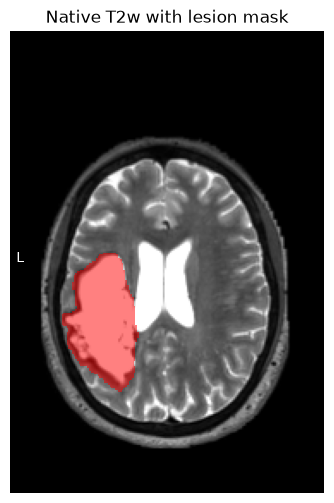

In [16]:
show_axial(native_background, native_slice, mask=native_overlay,
           title="Native T2w with lesion mask")

## 4. Run SYNcro

The first positional argument is the anatomical scan. The second is the mask that should follow the same deformation. Use `-h` to see the available options.

In [17]:
subprocess.run(["SYNcro.py", "-h"], check=True)

usage: SYNcro.py [-h] [--force-gpu {true,false,auto}] [-b] [-c] [-d DIRECTORY]
                 [--log {silent,verbose,debug}] [-v]
                 N [N ...]

Normalize NIfTI images with lesion maps.

positional arguments:
  N                     NIfTI images: first is anatomical (required), second
                        (optional) lesion map, third (optional) pathological

options:
  -h, --help            show this help message and exit
  --force-gpu {true,false,auto}
                        Force GPU usage (true), disable GPU (false), or auto-
                        detect (auto, default)
  -b, --bet             images are already brain extracted (default: False)
  -c, --ct              images are CT scans (default: False)
  -d DIRECTORY, --directory DIRECTORY
                        output directory (default: same as input)
  --log {silent,verbose,debug}
                        Set log level: silent (default), verbose, or debug
  -v, --version         show program's version numbe

CompletedProcess(args=['SYNcro.py', '-h'], returncode=0)

### Prepare the output directory

SYNcro requires an existing output directory. For a new run, we create a new directory and refuse to overwrite an earlier attempt. If a run fails, inspect the error and choose a new `OUTPUT_DIR` for the retry.

For later inspection, `RUN_SYNCRO = False` requires the `completed.txt` marker that this notebook writes when the processing command returns successfully. The output checks still run each time. Keep the original input paths when inspecting a saved run; this simple note does not check that you selected the same inputs.

In [18]:
completion_file = OUTPUT_DIR / "completed.txt"
if RUN_SYNCRO:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=False)
elif not completion_file.is_file():
    raise RuntimeError("No completed command is recorded here; use a new OUTPUT_DIR with RUN_SYNCRO = True")

### Normalize the scan and mask

`-d` selects the output directory. `--force-gpu false` keeps this example on CPU; `--log verbose` shows progress. Expect several minutes. With `check=True`, a failed command stops execution before the result cells.

In [19]:
if RUN_SYNCRO:
    subprocess.run([
        "SYNcro.py", str(anat), str(lesion), "-d", str(OUTPUT_DIR),
        "--force-gpu", FORCE_GPU, "--log", "verbose",
    ], check=True)
    completion_file.write_text(f"SYNcro command completed: {SYNCRO_VERSION}\n")
else:
    print("Inspecting saved results; normalization was not run")

INFO - dilation 0 smooth 3mm: /home/jovyan/syncro-freesurfer-handoff-2026-09-23/syncro_output/SYNcro_03se1rcp/sub-M2304_ses-262_acq-spc3p2_run-5_T2w_desc-lesion_mask.nii.gz
INFO - Running: /usr/local/bin/py_synthsr --i /home/jovyan/syncro-freesurfer-handoff-2026-09-23/syncro_output/SYNcro_03se1rcp/sub-M2304_ses-262_acq-spc3p2_run-5_T2w.nii.gz --o /home/jovyan/syncro-freesurfer-handoff-2026-09-23/syncro_output/SYNcro_03se1rcp/t1sub-M2304_ses-262_acq-spc3p2_run-5_T2w.nii.gz --cpu --threads 63


using CPU, hiding all CUDA_VISIBLE_DEVICES
Using general model from January 2023 (version 2)
/freesurfer/models/synthsr_v20_230130.h5
using 63 threads
predicting 1/1
Prediction without flipping
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
Prediction with flipping
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step

prediction  saved in: /home/jovyan/syncro-freesurfer-handoff-2026-09-23/syncro_output/SYNcro_03se1rcp/t1sub-M2304_ses-262_acq-spc3p2_run-5_T2w.nii.gz

If you use this tool in a publication, please cite:


Joint super-resolution and synthesis of 1 mm isotropic MP-RAGE volumes from clinical 
MRI exams with scans of different orientation, resolution and contrast
JE Iglesias, B Billot, Y Balbastre, A Tabari, J Conklin, RG Gonzalez, DC Alexander,
P Golland, BL Edlow, B Fischl, for the ADNI
NeuroImage, 118206 (2021)



SynthSR: a public AI tool to turn heterogeneous clinical brain scans into 
high-resolution T1-weighted images for 3D morphometry
JE Iglesias, B Billot, Y Balbastre, C Magdamo, S Arnold,

INFO - sub-M2304_ses-262_acq-spc3p2_run-5_T2w.nii.gz: min=0.0, max=571.0, interp=linear
INFO - sub-M2304_ses-262_acq-spc3p2_run-5_T2w_desc-lesion_mask.nii.gz: min=0.0, max=0.9999999999999998, interp=linear
INFO - Binarizing /home/jovyan/syncro-freesurfer-handoff-2026-09-23/syncro_output/wsub-M2304_ses-262_acq-spc3p2_run-5_T2w_desc-lesion_mask.nii.gz using threshold 0.5
INFO - SYNcro time: 105007 ms


## 5. Check the normalized results

SYNcro saves three images. Prefixes describe their processing history:

| Prefix | Image |
| --- | --- |
| `wbt1` | Warped, brain-extracted synthetic T1 |
| `w` before the scan name | Original T2w warped to MNI space |
| `w` before the mask name | Lesion mask warped to MNI space |

The synthetic image helps assess registration. The warped original retains the acquired contrast and is the image to inspect alongside the lesion mask.

In [20]:
warped_synth_t1 = OUTPUT_DIR / ("wbt1" + anat.name)
warped_anat = OUTPUT_DIR / ("w" + anat.name)
warped_lesion = OUTPUT_DIR / ("w" + lesion.name)
template = nib.load(MNI_TEMPLATE)

### Check the output grids

All three files should be readable, nonempty and on the template's grid. Compare both shape and affine before drawing overlays.

In [21]:
for path in (warped_synth_t1, warped_anat, warped_lesion):
    image = nib.load(path)
    if image.shape != template.shape or not np.allclose(image.affine, template.affine, atol=0.01, rtol=0):
        raise ValueError(f"Output does not match the MNI grid: {path.name}")
    data = np.asanyarray(image.dataobj)
    if not np.isfinite(data).all() or not np.any(data):
        raise ValueError(f"Empty or non-finite output: {path.name}")
    print(path.name, image.shape)

wbt1sub-M2304_ses-262_acq-spc3p2_run-5_T2w.nii.gz (182, 218, 182)
wsub-M2304_ses-262_acq-spc3p2_run-5_T2w.nii.gz (182, 218, 182)
wsub-M2304_ses-262_acq-spc3p2_run-5_T2w_desc-lesion_mask.nii.gz (182, 218, 182)


Check that the warped mask is still binary. We also measure its volume here, using the same calculation as for the native mask.

In [22]:
normalized_mask_image = nib.load(warped_lesion)
normalized_mask = np.asanyarray(normalized_mask_image.dataobj)
if not np.isin(normalized_mask, [0, 1]).all() or not np.any(normalized_mask):
    raise ValueError("The normalized mask is not a nonempty binary mask")
normalized_voxel_ml = abs(np.linalg.det(normalized_mask_image.affine[:3, :3])) / 1000
normalized_lesion_ml = np.count_nonzero(normalized_mask) * normalized_voxel_ml

### Prepare the MNI-space views

Reorder the image axes to RAS for plotting: left-to-right, posterior-to-anterior and inferior-to-superior. These outputs already share the orthogonal template grid, so no further resampling is needed. Select a slice through the lesion for the two figures below.

In [23]:
mni_background = nib.as_closest_canonical(nib.load(warped_anat)).get_fdata(dtype=np.float32)
mni_synthetic = nib.as_closest_canonical(nib.load(warped_synth_t1)).get_fdata(dtype=np.float32)
mni_overlay = nib.as_closest_canonical(normalized_mask_image).get_fdata(dtype=np.float32)
mni_outline = nib.as_closest_canonical(template).get_fdata(dtype=np.float32) > 0
mni_slice = int(np.argmax(mni_overlay.sum(axis=(0, 1))))

### Compare the synthetic brain with the template

The yellow outline comes from the MNI template. Look for systematic gaps or overshoot at the brain boundary and displaced internal landmarks. A plausible synthetic image does not establish that damaged tissue has been recovered.

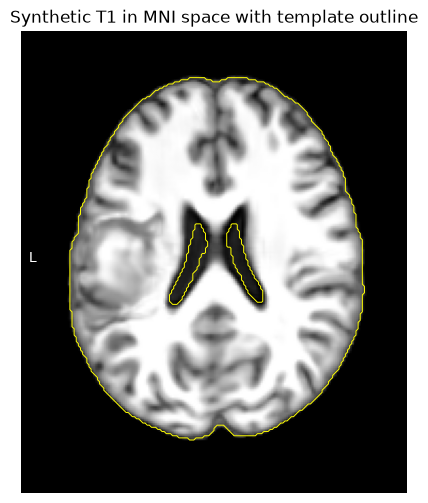

In [24]:
show_axial(mni_synthetic, mni_slice, outline=mni_outline,
           title="Synthetic T1 in MNI space with template outline")

### Check the original scan and mask

Now inspect the same slice of the warped T2w. Does the mask follow the lesion? Both received the same deformation, but mask smoothing and interpolation can change the boundary. Use the interactive viewer below to inspect other slices.

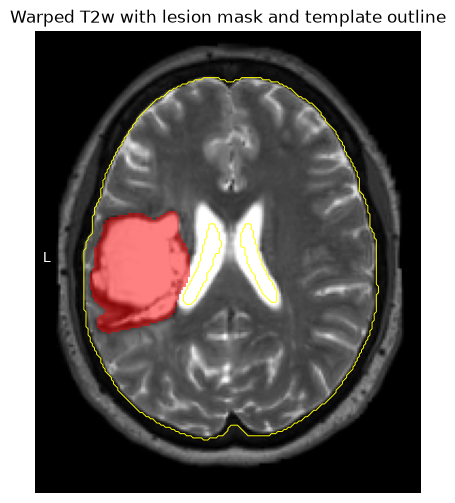

In [25]:
show_axial(mni_background, mni_slice, mask=mni_overlay, outline=mni_outline,
           title="Warped T2w with lesion mask and template outline")

### Compare lesion volumes

The percentage change combines deformation, smoothing, interpolation and re-binarization. It is a QC observation, not a pass/fail threshold. Investigate unexpected changes using the original anatomy and the overlays.

In [26]:
change = 100 * (normalized_lesion_ml - native_lesion_ml) / native_lesion_ml
print(f"Native volume: {native_lesion_ml:.1f} mL")
print(f"MNI volume:    {normalized_lesion_ml:.1f} mL")
print(f"Change:        {change:+.1f}%")

Native volume: 56.0 mL
MNI volume:    73.5 mL
Change:        +31.2%


### Explore the normalized result

The viewer combines the template, warped T2w and lesion mask. Inspect the whole lesion and other anatomical landmarks, rather than accepting the registration from a single slice or volume measurement.

In [27]:
nv_mni = NiiVue(height=450)
nv_mni.load_volumes([
    {"path": str(MNI_TEMPLATE), "colormap": "gray"},
    {"path": str(warped_anat), "colormap": "gray", "opacity": 0.6},
    {"path": str(warped_lesion), "colormap": "red", "cal_min": 0.5, "cal_max": 1, "opacity": 0.6},
])
nv_mni

## 6. Interpretation and next steps

Use the original scan and expert mask for participant lesion measurements. A synthetic T1 is not recovered tissue and should not be used to delineate the original lesion. Native-space volume describes the participant; normalized coordinates support spatial comparisons across participants.

To adapt the command, use `-c` for CT or `-b` for an already brain-extracted image. Set `FORCE_GPU = "true"` only in a configured GPU environment. Choose a new output directory whenever the inputs or processing options change.

If image transforms disagree, check their spatial alignment before changing headers. Copying sform to qform is appropriate only after verifying that the sforms agree and correctly locate both images. A header edit cannot replace registration or resampling.

For a cohort, repeat the same retrieval, writable-copy and QC steps for each scan–mask pair, with separate working and output directories. Start with a few inspected cases before scaling up. See the [Slurm notebook example](../workflows/papermill-slurm-submission-example.ipynb), keeping SYNcro's CPU-visibility limitation in mind.

## Dependencies in Jupyter/Python

Watermark records the Python environment used here. Keep this information together with the module names and SYNcro version printed at the start.

In [28]:
%load_ext watermark
%watermark
%watermark --iversions

neurodesktop_version = (
    os.environ.get("JUPYTER_IMAGE", "").split(":")[-1]
    or os.environ.get("NEURODESKTOP_VERSION", "unknown")
)
print("Neurodesktop version:", neurodesktop_version)

Last updated: 2026-09-23T07:15:17.445680+00:00

Python implementation: CPython
Python version       : 3.13.15
IPython version      : 9.17.1

Compiler    : GCC 15.3.0
OS          : Linux
Release     : 7.0.0-28-generic
Machine     : x86_64
Processor   : x86_64
CPU cores   : 64
Architecture: 64bit

ipyniivue : 2.4.4
matplotlib: 3.11.2
nibabel   : 5.4.2
numpy     : 2.3.5

Neurodesktop version: 2026-09-22
